# Podstawy metody k-means (k-średnich) i jej zastosowania

## 1. Definicja i cel metody
Algorytm k-means to jedna z najpopularniejszych metod **uczenia nienadzorowanego** (unsupervised learning) służąca do **klasteryzacji** (grupowania danych). Celem jest podział zbioru danych na $k$ rozłącznych grup (klastrów) w taki sposób, aby elementy wewnątrz jednej grupy były do siebie jak najbardziej podobne, a elementy z różnych grup — jak najbardziej odmienne.

Podobieństwo mierzymy zazwyczaj za pomocą **odległości euklidesowej** między punktami w przestrzeni wielowymiarowej.

$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

## 2. Działanie algorytmu krok po kroku

Proces grupowania przebiega iteracyjnie według następującego schematu:

1.  **Inicjalizacja**: Wybieramy liczbę $k$ (liczbę klastrów, które chcemy utworzyć) i losujemy $k$ punktów startowych, które stają się początkowymi środkami ciężkości grup, nazywanymi **centroidami**.
2.  **Przypisanie**: Każdy punkt ze zbioru danych przypisujemy do najbliższego centroidu. Tworzą się w ten sposób wstępne skupiska.
3.  **Aktualizacja**: Dla każdej nowo powstałej grupy obliczamy nowy środek ciężkości (średnią arytmetyczną współrzędnych wszystkich punktów w grupie). Ten nowy punkt staje się nowym centroidem.
4.  **Powtórzenie**: Powtarzamy kroki 2 i 3 tak długo, aż pozycje centroidów przestaną się zmieniać lub osiągnięta zostanie maksymalna liczba iteracji.



## 3. Zastosowania metody k-means

Metoda k-średnich znajduje zastosowanie wszędzie tam, gdzie chcemy odkryć naturalną strukturę danych bez posiadania wcześniejszych etykiet:

* **Segmentacja klientów**: Grupowanie bazy klientów na podstawie zachowań zakupowych, wieku czy lokalizacji w celu personalizacji ofert marketingowych.
* **Kompresja obrazów**: Redukcja liczby kolorów w obrazie poprzez grupowanie podobnych odcieni i zastępowanie ich uśrednionym kolorem (centroidem).
* **Wykrywanie anomalii**: Identyfikacja punktów, które znajdują się bardzo daleko od jakiegokolwiek centroidu, co może sugerować błędy w danych lub próby oszustwa (np. w systemach bankowych).
* **Bioinformatyka**: Klasyfikacja genów o podobnych wzorcach ekspresji, co pomaga w identyfikacji funkcji nieznanych wcześniej sekwencji DNA.
* **Analiza tekstu**: Grupowanie dokumentów lub artykułów tematycznych na podstawie częstości występowania określonych słów.



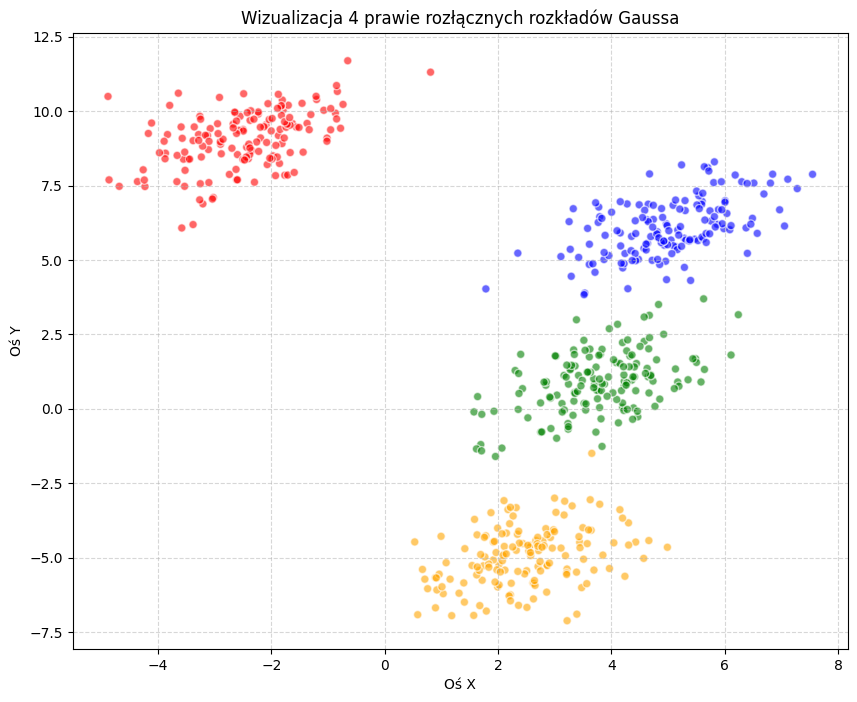

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generuj_klastry_gaussa(liczba_klastrow=3, punkty_na_klaster=100, rozsuniecie=10.0):
    """
    Generuje dwuwymiarowe rozkłady Gaussa z przypisanymi etykietami kolorów.
    """
    dane = []
    etykiety = []

    # Predefiniowana lista kolorów dla etykiet
    paleta_kolorow = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

    if liczba_klastrow > len(paleta_kolorow):
        print(f"Ostrzeżenie: Maksymalna liczba kolorów to {len(paleta_kolorow)}. Skalowanie do limitu.")
        liczba_klastrow = len(paleta_kolorow)

    # Inicjalizacja ziarna dla powtarzalności wyników
    np.random.seed(42)

    for i in range(liczba_klastrow):
        # Losowanie środka klastra (średniej) w taki sposób, by były rozproszone
        srednia = np.random.uniform(-rozsuniecie, rozsuniecie, size=2)

        # Macierz kowariancji określająca kształt "chmury" (tutaj kołowy/owalny)
        kowariancja = [[1, 0.5], [0.5, 1]]

        # Generowanie punktów z rozkładu wielowymiarowego normalnego
        punkty = np.random.multivariate_normal(srednia, kowariancja, punkty_na_klaster)

        dane.append(punkty)
        # Przypisujemy etykietę koloru do każdego punktu w klastrze
        etykiety.extend([paleta_kolorow[i]] * punkty_na_klaster)

    # Przekształcenie listy w format macierzy do wykresu
    wszystkie_punkty = np.vstack(dane)

    return wszystkie_punkty, etykiety

# Parametry metody
n_klastrow = 4
n_punktow = 150

# Generowanie danych
punkty, kolory = generuj_klastry_gaussa(liczba_klastrow=n_klastrow, punkty_na_klaster=n_punktow)

# Rysowanie wykresu 2D
plt.figure(figsize=(10, 8))
plt.scatter(punkty[:, 0], punkty[:, 1], c=kolory, alpha=0.6, edgecolors='w')
plt.title(f"Wizualizacja {n_klastrow} prawie rozłącznych rozkładów Gaussa")
plt.xlabel("Oś X")
plt.ylabel("Oś Y")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Wybór optymalnej liczby klastrów

Jednym z wyzwań metody jest konieczność podania parametru $k$ przed rozpoczęciem obliczeń. Najczęściej stosujemy tzw. **Metodę Łokcia** (Elbow Method). Polega ona na obliczeniu sumy kwadratów odległości wewnątrz klastrów (WCSS - Within-Cluster Sum of Squares) dla różnych wartości $k$.

$$WCSS = \sum_{j=1}^{k} \sum_{i \in C_j} ||x_i - \mu_j||^2$$

Wykres WCSS zazwyczaj gwałtownie spada, a następnie wyrównuje się. Punkt, w którym spadek przestaje być gwałtowny (przypomina zgięcie łokcia), sugeruje optymalną liczbę grup.



## 1. Procedura wyznaczania "łokcia"
Metoda łokcia opiera się na analizie zmienności wewnątrz grup w funkcji liczby klastrów. Proces przebiega w następujących etapach:

1. **Wybór zakresu**: Ustalamy zakres poszukiwań dla parametru $k$ (np. od 1 do 10).
2. **Obliczenia iteracyjne**: Dla każdej wartości $k$ z wybranego zakresu uruchamiamy algorytm k-means.
3. **Ekstrakcja WCSS**: Po każdej konwergencji algorytmu odczytujemy wartość wskaźnika **WCSS** (Within-Cluster Sum of Squares), zwanego również inercją:
   $$WCSS = \sum_{j=1}^{k} \sum_{i \in C_j} ||x_i - \mu_j||^2$$
4. **Wizualizacja**: Tworzymy wykres liniowy, gdzie na osi odciętych (X) znajduje się liczba klastrów $k$, a na osi rzędnych (Y) wartość $WCSS$.
5. **Identyfikacja punktu przegięcia**: Szukamy punktu, po którym spadek $WCSS$ staje się znacznie wolniejszy (krzywa ulega spłaszczeniu). Ten punkt matematycznie reprezentuje kompromis między precyzją (niskie błędy wewnątrz grup) a złożonością modelu (liczba klastrów).



## 2. Ograniczenia metody
Mimo powszechnego stosowania, metoda łokcia posiada istotne wady:

* **Subiektywność**: W wielu rzeczywistych zbiorach danych "łokieć" nie jest wyraźnie zarysowany. Krzywa może opadać płynnie, co sprawia, że interpretacja wizualna staje się niejednoznaczna.
* **Problem klastrów o różnej gęstości**: Metoda słabo radzi sobie, gdy naturalne skupiska danych mają bardzo zróżnicowane rozmiary lub gęstości.
* **Brak globalnego optimum**: Algorytm k-means (będący podstawą metody) może utknąć w minimach lokalnych, co zniekształca wykres $WCSS$. Wymaga to wielokrotnych uruchomień (parametr `n_init`).
* **Niezgodność z kształtem**: Metoda łokcia (podobnie jak k-means) zakłada sferyczność klastrów. Jeśli dane tworzą wydłużone lub zakrzywione struktury, "łokieć" może sugerować błędną liczbę grup.

## 3. Złożoność obliczeniowa
Złożoność wyznaczenia optymalnego $k$ jest iloczynem złożoności pojedynczego przebiegu k-means oraz liczby testowanych wartości $k$.

Przyjmując:
* $N$ - liczba punktów danych
* $d$ - liczba wymiarów
* $i$ - liczba iteracji do konwergencji
* $K_{max}$ - maksymalna testowana liczba klastrów

Złożoność wynosi:
$$O(K_{max} \cdot N \cdot d \cdot i)$$

Dla dużych zbiorów danych ($N \gg 1$) metoda staje się kosztowna, gdyż wymaga wielokrotnego przeliczania odległości wszystkich punktów od wszystkich centroidów dla każdej badanej wartości $k$.

## 4. Wiarygodność szacowania
Wiarygodność metody łokcia oceniamy jako **średnią**:

* **Wysoka**: W przypadku dobrze odseparowanych, kulistych klastrów o zbliżonej wariancji (np. sztucznie generowane rozkłady Gaussa).
* **Niska**: W danych silnie zaszumionych lub gdy klastry nakładają się na siebie.

W celu zwiększenia wiarygodności szacowania wartości $k$, stosujemy metody uzupełniające:
1. **Analiza Sylwetki (Silhouette Analysis)**: Mierzy, jak blisko każdego punktu w jednym klastrze znajdują się punkty w sąsiednich klastrach.
2. **Statystyka Gap (Gap Statistic)**: Porównuje logarytm $WCSS$ z oczekiwaną wartością w rozkładzie jednostajnym (bez klastrów). Jest uważana za bardziej obiektywną matematycznie.

k=1: 23090.46
k=2: 8703.86
k=3: 3127.40
k=4: 1116.86
k=5: 971.47
k=6: 854.54
k=7: 722.69
k=8: 605.77
k=9: 563.59
k=10: 526.33


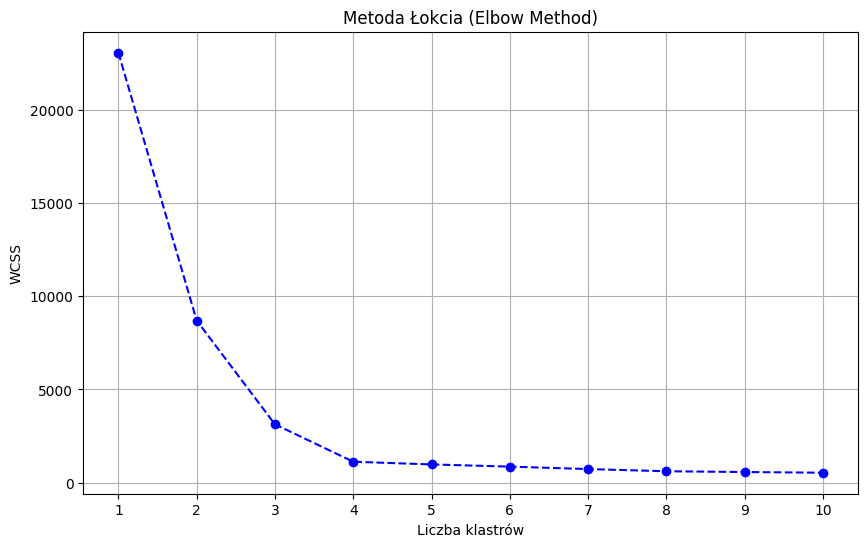

In [ ]:
#wyznaczyć wccss w zakresie od 1 do 10
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Zakładam, że zmienna 'punkty' jest już dostępna z Twojego kodu

wcss = []
zakres_k = range(1, 11)

for k in zakres_k:
    # Tworzenie modelu KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(punkty)
    # inertia_ to atrybut przechowujący wartość WCSS
    wcss.append(kmeans.inertia_)
    print(f"k={k}: {kmeans.inertia_:.2f}")

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(zakres_k, wcss, marker='o', linestyle='--', color='b')
plt.title('Metoda Łokcia (Elbow Method)')
plt.xlabel('Liczba klastrów')
plt.ylabel('WCSS')
plt.xticks(zakres_k)
plt.grid(True)
plt.show()

## Przygotuj analizę k-means punktów. Zrób rysunki klastrów dla k=3, k=4

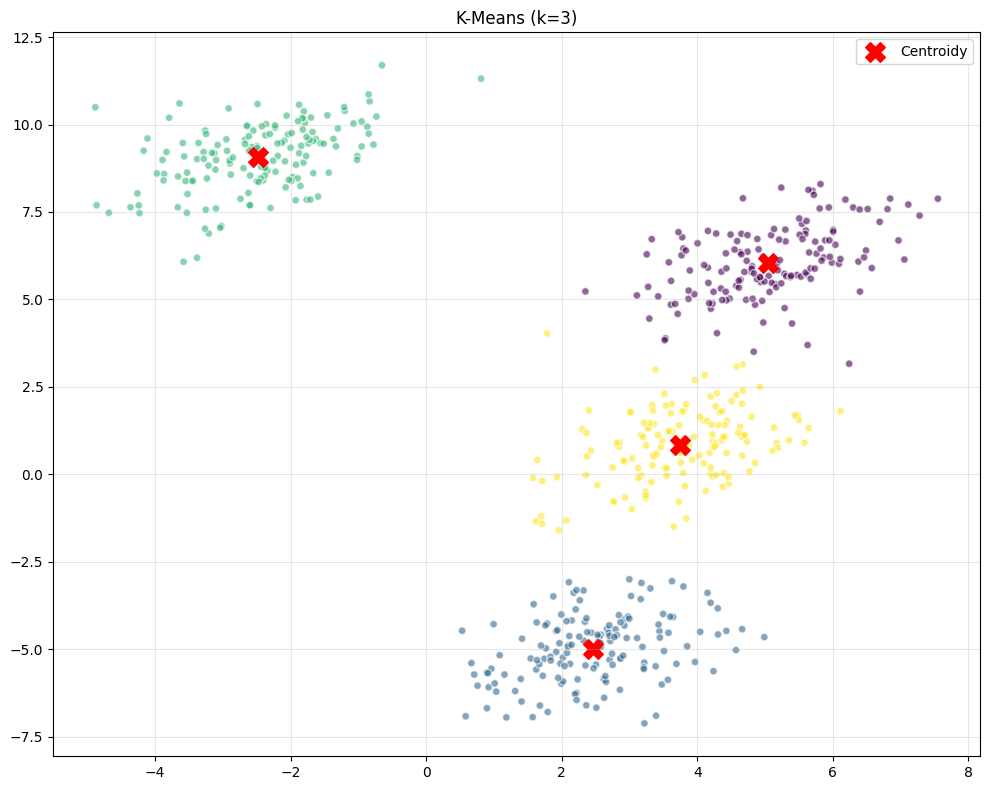

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# (Tutaj powinna znaleźć się funkcja generuj_klastry_gaussa z poprzedniego kroku
# oraz wygenerowanie zmiennej 'punkty')

fig, ax = plt.subplots(figsize=(10, 8))

# --- Analiza dla k=3 ---
k=4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(punkty)
centroids = kmeans.cluster_centers_

ax.scatter(punkty[:, 0], punkty[:, 1], c=labels, cmap='viridis', s=30, alpha=0.6, edgecolors='w')
ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroidy')
ax.set_title('K-Means (k=3)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Przygotuj predykcję dla wybranego punktu. Zrób wizualizację która pokoloruje wybrany punkt kolorem punktów z klastr, do którego ten punkt należy.

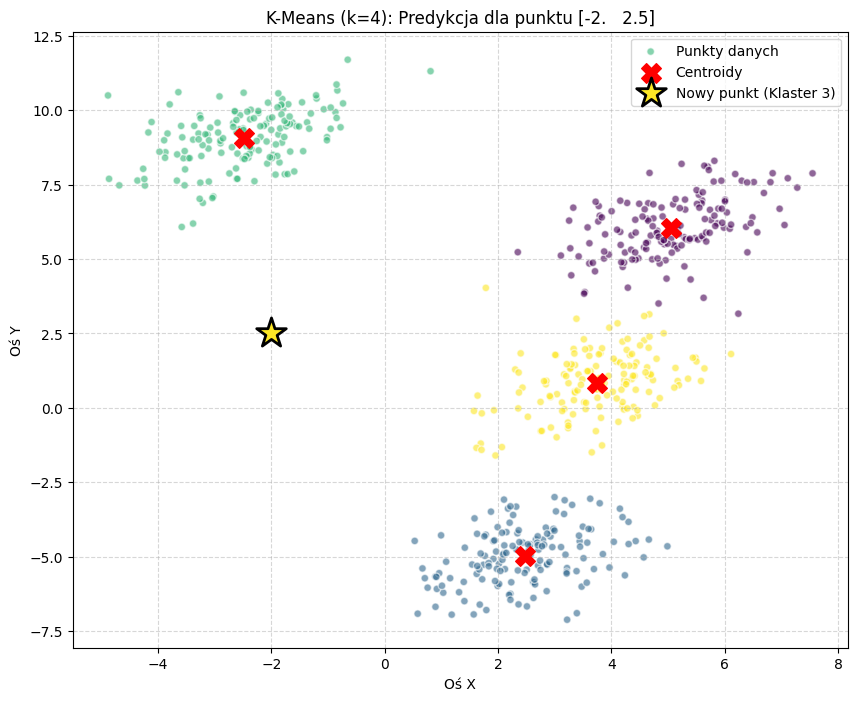

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- TWOJA FUNKCJA GENERUJĄCA DANE ---
def generuj_klastry_gaussa(liczba_klastrow=3, punkty_na_klaster=100, rozsuniecie=10.0):
    dane = []
    etykiety = []
    paleta_kolorow = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

    if liczba_klastrow > len(paleta_kolorow):
        liczba_klastrow = len(paleta_kolorow)

    np.random.seed(42)

    for i in range(liczba_klastrow):
        srednia = np.random.uniform(-rozsuniecie, rozsuniecie, size=2)
        kowariancja = [[1, 0.5], [0.5, 1]]
        punkty_klastra = np.random.multivariate_normal(srednia, kowariancja, punkty_na_klaster)
        dane.append(punkty_klastra)
        etykiety.extend([paleta_kolorow[i]] * punkty_na_klaster)

    wszystkie_punkty = np.vstack(dane)
    return wszystkie_punkty, etykiety

# --- 1. Generowanie danych ---
n_klastrow = 4
n_punktow = 150
punkty, _ = generuj_klastry_gaussa(liczba_klastrow=n_klastrow, punkty_na_klaster=n_punktow)

# --- 2. Trening modelu K-Means ---
# Ustawiamy liczbę klastrów taką samą, jak przy generowaniu (lub inną, jeśli chcemy eksperymentować)
kmeans = KMeans(n_clusters=n_klastrow, random_state=42, n_init=10)
# Trenujemy model na wygenerowanych punktach
kmeans_labels = kmeans.fit_predict(punkty)
centroids = kmeans.cluster_centers_

# --- 3. Predykcja dla nowego punktu ---
# Losujemy punkt w zakresie danych, żeby był widoczny na wykresie
x_min, x_max = punkty[:, 0].min(), punkty[:, 0].max()
y_min, y_max = punkty[:, 1].min(), punkty[:, 1].max()

# Przykładowy nowy punkt (możesz wpisać własne współrzędne np. [[0, 0]])
nowy_punkt = np.array([[-2, 2.5]])
#np.array([[np.random.uniform(x_min, x_max), np.random.uniform(y_min, y_max)]])

# Przewidujemy etykietę (klaster) dla tego punktu
nowy_label = kmeans.predict(nowy_punkt)[0]

# --- 4. Wizualizacja ---
fig, ax = plt.subplots(figsize=(10, 8))

# Ustawiamy sztywne limity dla mapy kolorów, aby
# etykieta 0 zawsze miała ten sam kolor na obu scatterach
vmin = 0
vmax = n_klastrow - 1
cmap = 'viridis' # Możesz zmienić na 'plasma', 'jet', etc.

# A. Rysujemy punkty danych (pokolorowane wg tego, co znalazł K-Means)
scatter = ax.scatter(punkty[:, 0], punkty[:, 1],
                     c=kmeans_labels,  # Ważne: używamy etykiet z modelu!
                     cmap=cmap,
                     vmin=vmin, vmax=vmax,
                     alpha=0.6, edgecolors='w', s=30, label='Punkty danych')

# B. Rysujemy Centroidy
ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroidy', zorder=10)

# C. Rysujemy NOWY PUNKT z predykcji
ax.scatter(nowy_punkt[:, 0], nowy_punkt[:, 1],
           c=[nowy_label],    # Kolor zgodny z przewidzianym klastrem
           cmap=cmap,
           vmin=vmin, vmax=vmax, # Te same limity co w punkcie A
           s=500, marker='*', edgecolors='black', linewidth=2, zorder=11,
           label=f'Nowy punkt (Klaster {nowy_label})')

ax.set_title(f"K-Means (k={n_klastrow}): Predykcja dla punktu {np.round(nowy_punkt[0], 2)}")
ax.set_xlabel("Oś X")
ax.set_ylabel("Oś Y")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

# WCSS a wymiarowość przestrzeni danych

Wartość wskaźnika WCSS (Within-Cluster Sum of Squares) jest silnie uzależniona od liczby wymiarów $d$ analizowanego zbioru danych. Zjawisko to wiąże się bezpośrednio z matematycznymi właściwościami odległości euklidesowej w przestrzeniach wielowymiarowych.

## 1. Wzrost wartości bezwzględnej WCSS
WCSS definiujemy jako sumę kwadratów odległości euklidesowych. Wraz ze wzrostem liczby wymiarów $d$, odległość między dowolnymi dwoma punktami $p$ i $q$ statystycznie rośnie:

$$d(p, q)^2 = \sum_{i=1}^{d} (p_i - q_i)^2$$

Każdy dodatkowy wymiar dodaje kolejny składnik do sumy, co powoduje, że:
* Wartości WCSS w przestrzeniach o wysokim wymiarze (np. $d=100$) są rzędami wielkości większe niż w przestrzeni 2D.
* Skale WCSS stają się nieporównywalne między zbiorami o różnej liczbie cech.

## 2. Przekleństwo wymiarowości (Curse of Dimensionality)
Wysoka liczba wymiarów wpływa negatywnie na wiarygodność WCSS jako miary zwartości klastrów:

1.  **Rozmycie odległości**: W przestrzeniach wysokowymiarowych różnica między odległością do najbiższego i najdalszego sąsiada dąży do zera. Wszystkie punkty stają się "równie daleko" od siebie.
2.  **Utrata struktury**: Wskaźnik WCSS przestaje wyraźnie reagować na faktyczne grupowanie danych, ponieważ szum w nadmiarowych wymiarach dominuje nad sygnałem w wymiarach istotnych.



## 3. Problem rzadkości danych (Data Sparsity)
Wraz ze wzrostem wymiarowości, objętość przestrzeni rośnie wykładniczo ($V \propto L^d$). Przy stałej liczbie punktów $N$, dane stają się ekstremalnie rzadkie.
* W rzadkiej przestrzeni centroidy klastrów słabiej reprezentują "środek" grupy.
* Minimalizacja WCSS może prowadzić do overfittingu — algorytm znajduje klastry tam, gdzie ich nie ma, jedynie ze względu na losowe rozproszenie punktów w próżni wielowymiarowej.

## 4. Wpływ na metodę łokcia
Zjawiska te mają bezpośredni wpływ na diagnostykę modelu:
* **Zacieranie "łokcia"**: W danych o bardzo wysokim wymiarze wykres WCSS często staje się niemal liniowy lub wykazuje bardzo słabe przegięcie, co uniemożliwia jednoznaczną identyfikację optymalnego $k$.
* **Wrażliwość na skalowanie**: Przy wielu wymiarach cechy o większych zakresach wartości dominują w obliczeniach WCSS. Bez uprzedniej standaryzacji (np. StandardScaler), WCSS mierzy głównie zmienność cechy o największej skali.

## 5. Przeciwdziałanie
Aby zachować sensowność analizy WCSS w problemach wielowymiarowych, stosujemy:

1.  **Redukcję wymiarowości (PCA)**: Rzutujemy dane na przestrzeń o niższym wymiarze (np. 2D lub 3D) przed uruchomieniem k-means. Pozwala to na usunięcie szumu i lepszą wizualizację "łokcia".
2.  **Normalizację**: Sprowadzenie wszystkich cech do wspólnej skali (np. od 0 do 1), aby każdy wymiar miał równy wkład w wartość WCSS.
3.  **Wybór cech (Feature Selection)**: Odrzucenie wymiarów nieistotnych, które zwiększają wartość WCSS, nie wnosząc informacji o strukturze klastrów.


#Zadanie
##Sprawdź czy metoda k-means zadziała na takim zbiorze obrazów.
###Jest to zbiór , który był już uzywany na wcześniejszych laboratoriach więc warto porównać


Kroki

0) wrzucic do k-means a nóz
1) pca
2) momnet hu/hough/...
3) klalowanie std,normalscaler Xi=max(Xi)/255


In [40]:

!wget https://github.com/olafbar/credo_files/raw/refs/heads/main/images_4class.zip
!unzip -oq -j images_4class.zip -d  IMG
# ! rm -rf IMG
!ls -lh IMG | wc -l
#


--2026-01-20 12:24:09--  https://github.com/olafbar/credo_files/raw/refs/heads/main/images_4class.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/olafbar/credo_files/refs/heads/main/images_4class.zip [following]
--2026-01-20 12:24:10--  https://raw.githubusercontent.com/olafbar/credo_files/refs/heads/main/images_4class.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5757268 (5.5M) [application/zip]
Saving to: ‘images_4class.zip.4’

images_4class.zip.4 100%[===================>]   5.49M  --.-KB/s    in 0.08s   

2026-01-20 12:24:11 (69.7 MB/s) - ‘images_4class.zip.4’ saved [5757268/57

Rozpoczynam ekstrakcję zaawansowanych cech...
PCA zredukowało cechy do 4 wymiarów.
NOWA DOKŁADNOŚĆ (z nowymi cechami): 74.88%


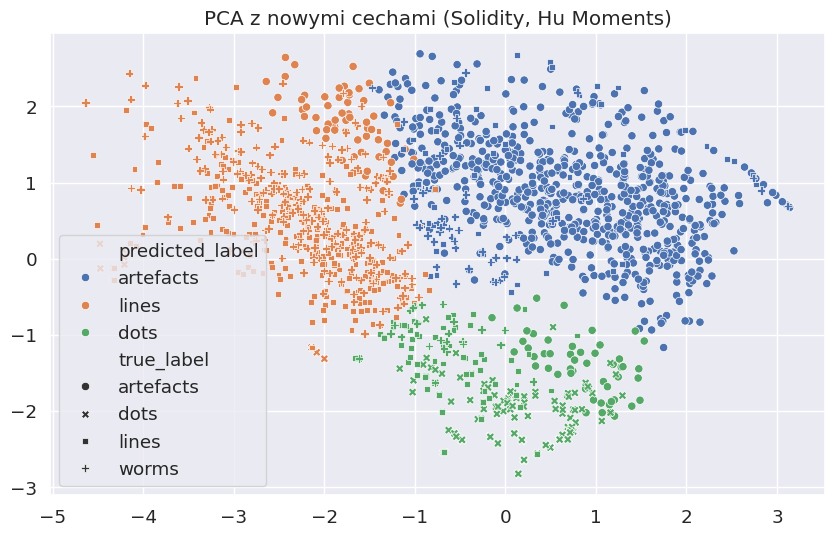


--- Generowanie Macierzy Pomyłek (Heatmap) ---


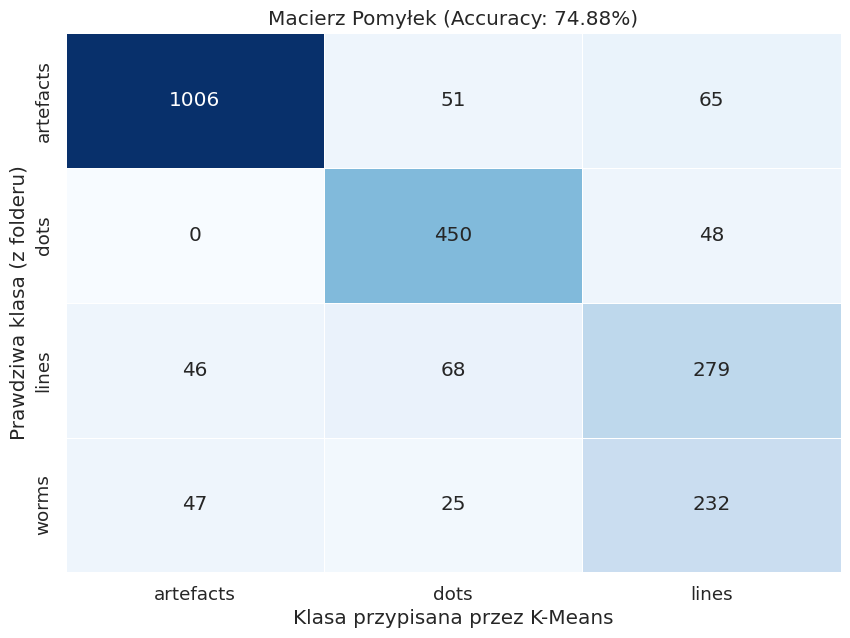


--- Szczegółowy raport klasyfikacji ---
              precision    recall  f1-score   support

   artefacts       0.92      0.90      0.91      1122
        dots       0.76      0.90      0.82       498
       lines       0.45      0.71      0.55       393
       worms       0.00      0.00      0.00       304

    accuracy                           0.75      2317
   macro avg       0.53      0.63      0.57      2317
weighted avg       0.68      0.75      0.71      2317



In [49]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# ... (Pobieranie danych bez zmian - pomijam dla czytelności) ...
if not os.path.exists('images_4class.zip'):
    !wget https://github.com/olafbar/credo_files/raw/refs/heads/main/images_4class.zip
    !unzip -q images_4class.zip
base_path = 'images'
categories = ['artefacts', 'dots', 'lines', 'worms']

# ==========================================
# ULEPSZONA EKSTRAKCJA CECH
# ==========================================
def extract_advanced_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None

    _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None

    c = max(contours, key=cv2.contourArea)

    # 1. Podstawowe
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    if perimeter == 0: return None # Odrzucamy błędy

    # 2. Kształt (Roundness)
    roundness = (4 * np.pi * area) / (perimeter ** 2)

    # 3. Prostokąt otaczający
    x, y, w, h = cv2.boundingRect(c)
    aspect_ratio = float(w) / h if h != 0 else 0
    rect_area = w * h
    extent = area / rect_area if rect_area > 0 else 0 # Jak bardzo wypełnia prostokąt

    # 4. Otoczka wypukła (Convex Hull) - KLUCZOWE DLA ROBAKÓW
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    # 5. Momenty Hu (tylko pierwszy moment - najsilniejszy)
    moments = cv2.moments(c)
    hu_moments = cv2.HuMoments(moments)
    # Log scale dla Hu Moments, bo mają ogromny zakres
    hu1 = -1 * np.sign(hu_moments[0][0]) * np.log10(np.abs(hu_moments[0][0])) if hu_moments[0][0] != 0 else 0

    return [area, perimeter, roundness, aspect_ratio, extent, solidity, hu1]

# ==========================================
# TWORZENIE DATASETU
# ==========================================
data = []
true_labels = []
feature_names = ['area', 'perimeter', 'roundness', 'aspect_ratio', 'extent', 'solidity', 'hu1']

print("Rozpoczynam ekstrakcję zaawansowanych cech...")
for cat in categories:
    cat_path = os.path.join(base_path, cat)
    if not os.path.exists(cat_path): continue
    for file_name in os.listdir(cat_path):
        features = extract_advanced_features(os.path.join(cat_path, file_name))
        if features is not None:
            data.append(features)
            true_labels.append(cat)

df = pd.DataFrame(data, columns=feature_names)

# ==========================================
# PREPROCESSING (ULEPSZONY)
# ==========================================
# Zamiast zwykłego StandardScalera, używamy logarytmowania dla Area/Perimeter
# Ponieważ te wartości rosną wykładniczo.
df['log_area'] = np.log1p(df['area'])
df['log_perimeter'] = np.log1p(df['perimeter'])

# Wybieramy cechy do modelu (bez surowego area/perimeter)
features_to_use = ['log_area', 'log_perimeter', 'roundness', 'aspect_ratio', 'extent', 'solidity', 'hu1']

# Skalowanie
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_to_use])

# PCA (Ważne przy większej liczbie cech)
pca = PCA(n_components=0.95) # Zachowaj 95% informacji
X_pca = pca.fit_transform(X_scaled)
print(f"PCA zredukowało cechy do {X_pca.shape[1]} wymiarów.")

# ==========================================
# K-MEANS + ACCURACY
# ==========================================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20) # n_init=20 dla stabilności
df['cluster'] = kmeans.fit_predict(X_pca)
df['true_label'] = true_labels

# Mapowanie (tak jak wcześniej)
cluster_map_raw = {}
for i in range(4):
    cluster_data = df[df['cluster'] == i]
    if not cluster_data.empty:
        cluster_map_raw[i] = cluster_data['true_label'].mode()[0]
    else:
        cluster_map_raw[i] = "unknown"

df['predicted_label'] = df['cluster'].map(cluster_map_raw)
accuracy = accuracy_score(df['true_label'], df['predicted_label'])

print("="*40)
print(f"NOWA DOKŁADNOŚĆ (z nowymi cechami): {accuracy:.2%}")
print("="*40)

# Wizualizacja PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['predicted_label'], style=df['true_label'], palette='deep')
plt.title("PCA z nowymi cechami (Solidity, Hu Moments)")
plt.show()

# ==========================================
# 6. WIZUALIZACJA MACIERZY POMYŁEK
# ==========================================

print("\n--- Generowanie Macierzy Pomyłek (Heatmap) ---")

# Tworzymy tabelę krzyżową: Prawdziwe Etykiety vs Przewidziane Etykiety
# Używamy 'predicted_label', którą stworzyliśmy w poprzednim kroku (zmapowane nazwy)
crosstab = pd.crosstab(df['true_label'], df['predicted_label'])

# Ustawienia wykresu
plt.figure(figsize=(10, 7))
sns.heatmap(
    crosstab,
    annot=True,     # Pokaż liczby w kratkach
    fmt='d',        # Format liczb (d = całkowite)
    cmap='Blues',   # Kolorystyka
    linewidths=.5,  # Przerwy między kratkami
    cbar=False      # Ukryj pasek legendy koloru dla czystości
)

plt.title(f'Macierz Pomyłek (Accuracy: {accuracy:.2%})')
plt.ylabel('Prawdziwa klasa (z folderu)')
plt.xlabel('Klasa przypisana przez K-Means')
plt.show()

# ==========================================
# (Opcjonalnie) Raport tekstowy
# ==========================================
from sklearn.metrics import classification_report
print("\n--- Szczegółowy raport klasyfikacji ---")
# Zero_division=0 ukrywa ostrzeżenia, jeśli jakiś klaster jest pusty
print(classification_report(df['true_label'], df['predicted_label'], zero_division=0))